# Hypothesis Testing — Four Claims About the Housing Market

**Author:** Mahdi Tarrah

**Data:** Divar real-estate listings — 1,000,000 ads, 61 columns

Four widely held beliefs about the market, tested on the data. With hundreds of thousands of
rows almost any difference comes out "significant", so every test reports **how large** the
effect is (Cohen's d, price ratio) next to the p-value, and is repeated **inside each property
type** so that a difference in the mix of apartments and villas is not mistaken for an effect.

## آماده‌سازی

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import arabic_reshaper
from bidi.algorithm import get_display
import jdatetime
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import branca.colormap as cm

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")
DIVAR_PATH = DATA_DIR / "Divar.csv"
CITY_CLASS_PATH = DATA_DIR / "iran_city_classification.csv"

# every generated map and figure goes here
MAPS_DIR = Path("../outputs/maps")
MAPS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# columns used anywhere in this notebook (the long free-text columns are left out to save memory)
DIVAR_COLUMNS = [
    "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug", "created_at_month",
    "rent_value", "credit_value", "price_value", "land_size", "building_size", "construction_year",
    "has_business_deed", "location_latitude", "location_longitude",
    "has_balcony", "has_elevator", "has_parking", "has_warehouse",
    "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna",
]

divar = pd.read_csv(DIVAR_PATH, usecols=DIVAR_COLUMNS, low_memory=False)
print(divar.shape)

(1000000, 23)


In [3]:
# shared helpers

JALALI_MONTHS = ["فروردین", "اردیبهشت", "خرداد", "تیر", "مرداد", "شهریور",
                 "مهر", "آبان", "آذر", "دی", "بهمن", "اسفند"]
FA_DIGITS = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")
TRUE_FALSE = {True: 1, "true": 1, "True": 1, False: 0, "false": 0, "False": 0}


def fix_fa(text):
    """Reshape Persian text so matplotlib draws it right-to-left."""
    return get_display(arabic_reshaper.reshape(str(text)))


def to_jalali(ts):
    return jdatetime.date.fromgregorian(date=pd.Timestamp(ts).date())


def to_flag(series):
    """Mixed bool / 'true' / 'false' values to 1 / 0; anything else (e.g. 'unselect') becomes NaN."""
    return series.map(TRUE_FALSE)


def parse_year(series):
    """construction_year is text with Persian digits; 'before 1370' is mapped to 1369."""
    text = series.astype("string").str.translate(FA_DIGITS).str.replace("قبل از 1370", "1369", regex=False)
    return pd.to_numeric(text, errors="coerce")


def log_iqr_mask(series, k=1.5):
    """True for positive values inside the IQR fence computed on the log scale.

    Prices and areas are heavily right-skewed, so a plain IQR would cut genuinely expensive or large
    properties; on the log scale the fence only removes typos such as 10,000,000 m2 or 1e15 Toman."""
    logs = np.log(series.where(series > 0))
    q1, q3 = logs.quantile([0.25, 0.75])
    iqr = q3 - q1
    return logs.between(q1 - k * iqr, q3 + k * iqr)


def cohen_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

---
# آزمون فرض

## آزمون ۱ — آیا متراژ خانه‌ها در کلان‌شهرها کمتر از شهرهای کوچک است؟

In [4]:
# libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

```
H0:  mean(megacity) >= mean(small city)
H1:  mean(megacity) <  mean(small city)
```

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The claim is that the mean area in megacities is smaller than in small cities</li>
<li>H0 must carry the equality, so H0 is mega >= small and H1 is mega < small</li>
<li>That makes it a one-sided left test</li>
<li>Megacity is on the left of the hypothesis, so it must be the first sample in the test as well</li>
</ul>
</font></div>

In [5]:
# load data

need_columns = ['building_size','city_slug','cat2_slug','cat3_slug']
df = pd.read_csv('../data/Divar.csv',usecols=need_columns)
df.shape

(1000000, 4)

In [6]:
# city classes

cities = pd.read_csv('../data/iran_city_classification.csv')
print(cities.shape)
print(cities.head())
print(cities.columns)

(240, 2)
      نام شهر دسته‌بندی
0       karaj  کلان‌شهر
1      tehran  کلان‌شهر
2     mashhad  کلان‌شهر
3       ahvaz  کلان‌شهر
4  kermanshah  کلان‌شهر
Index(['نام شهر', 'دسته‌بندی'], dtype='str')


In [7]:
# class counts

print(cities[cities.columns[1]].value_counts())

دسته‌بندی
شهر کوچک    231
کلان‌شهر      9
Name: count, dtype: int64


In [8]:
# join files

data = df.merge(cities,left_on='city_slug',right_on=cities.columns[0],how='left')
print(data.shape)
data = data.rename(columns={cities.columns[1]: 'city_class'})
data = data.drop(columns=['نام شهر'])
print(data.head())

(1000000, 6)
          cat2_slug       cat3_slug city_slug  building_size city_class
0    temporary-rent           villa     karaj          500.0   کلان‌شهر
1  residential-sell  apartment-sell    tehran           60.0   کلان‌شهر
2  residential-rent  apartment-rent    tehran          132.0   کلان‌شهر
3   commercial-rent     office-rent    tehran           90.0   کلان‌شهر
4  residential-sell  apartment-sell   mashhad          115.0   کلان‌شهر


In [9]:
# unmatched ads

data['city_class'].isna().sum()

np.int64(36723)

In [10]:
# property types

print(data['cat2_slug'].value_counts())
print(data['cat3_slug'].value_counts())

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64


In [11]:
# filter

result = data[(data['city_class'].notna()) & (data['cat2_slug'].isin(['residential-sell','residential-rent'])) & (data['cat3_slug'] != 'plot-old')].copy()

print(result.shape)
print(result['city_class'].value_counts())

(684456, 5)


city_class
کلان‌شهر    358402
شهر کوچک    326054
Name: count, dtype: int64


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Joined the two files on the city name</li>
<li>36,723 ads got no class and were dropped</li>
<li>Kept only residential ads and removed plot-old, which is land, not a house</li>
</ul>
</font></div>

In [12]:
# clean area

result.loc[ result['building_size'] <= 0 ,'building_size'] = np.nan

def clean_outliers(data, column):
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25),logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1-1.5*iqr,q3+1.5*iqr),column] = np.nan
    return data

print('before:', result['building_size'].isna().sum())
result = clean_outliers(result, 'building_size')
print('after:', result['building_size'].isna().sum())

result = result.dropna(subset=['building_size'])

print(result.shape)
print(result['building_size'].describe())
print(result['city_class'].value_counts())

result['city_class'] = result['city_class'].map({'کلان‌شهر': 'megacity', 'شهر کوچک': 'small city'})

before: 42
after: 23411
(661045, 5)
count    661045.000000
mean        108.525991
std          49.373708
min          32.000000
25%          75.000000
50%          98.000000
75%         130.000000
max         320.000000
Name: building_size, dtype: float64
city_class
کلان‌شهر    347389
شهر کوچک    313656
Name: count, dtype: int64


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Cleaned the area the same way as Q8, 3.4% outliers removed, range 32 to 320 m</li>
<li>The IQR bounds are computed on the pooled data, not per group, otherwise the two groups would be trimmed by different rules and the comparison would be invalid</li>
</ul>
</font></div>

                  mean  median        std   count
city_class                                       
megacity    108.147993   100.0  49.913726  347389
small city  108.944643    97.0  48.765295  313656


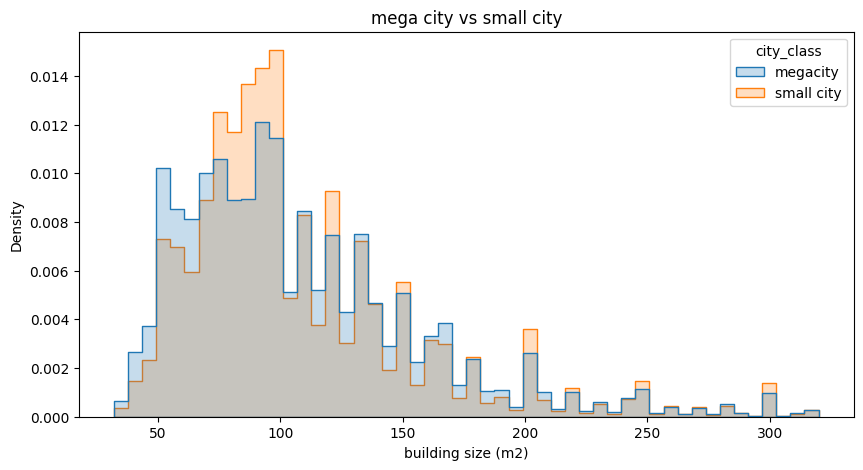

In [13]:
# group stats

print(result.groupby('city_class')['building_size'].agg(['mean','median','std','count']))

plt.figure(figsize=(10, 5))
sns.histplot(data=result, x='building_size',hue='city_class',bins=50,stat='density',common_norm=False,element='step')
plt.xlabel('building size (m2)')
plt.title('mega city vs small city')
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The gap between the two means is under one metre</li>
<li>The medians point the other way</li>
<li>Neither group looks normal on the histogram</li>
</ul>
</font></div>

In [14]:
# label check

result['city_class'].value_counts()

city_class
megacity      347389
small city    313656
Name: count, dtype: int64

In [15]:
# two samples

mega = result[result['city_class'] == 'megacity']['building_size']
small = result[result['city_class'] == 'small city']['building_size']
print(len(mega),len(small))

print('megacity:',stats.shapiro(mega.sample(5000,random_state=42)))
print('small:',stats.shapiro(small.sample(5000,random_state=42)))

347389 313656
megacity: ShapiroResult(statistic=np.float64(0.8982540874138423), pvalue=np.float64(1.6771819801819132e-49))
small: ShapiroResult(statistic=np.float64(0.873663907523583), pvalue=np.float64(3.1717403163579767e-53))


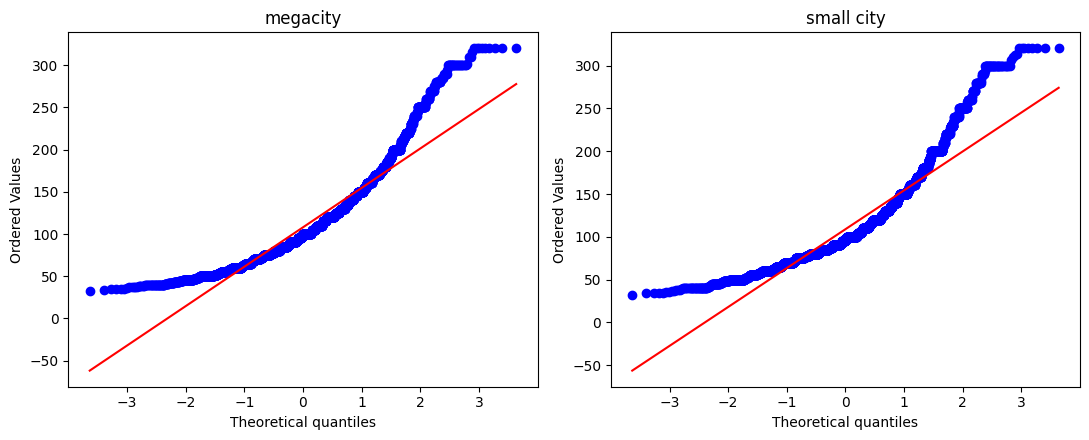

In [16]:
# q-q plot

fig, axes = plt.subplots(1,2,figsize=(11,4.5))

stats.probplot(mega.sample(5000,random_state=42),dist='norm',plot=axes[0])
axes[0].set_title('megacity')

stats.probplot(small.sample(5000,random_state=42),dist='norm',plot=axes[1])
axes[1].set_title('small city')

plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Shapiro tests normality, but with samples this large it rejects on any tiny deviation, so a bigger sample would make it less informative, not more. scipy itself warns that its p-value is unreliable above 5000 rows</li>
<li>So instead of enlarging the sample I read the Q-Q plot, which shows how far the data is from normal and where, not just yes or no</li>
<li>What actually matters is the central limit theorem: with hundreds of thousands of rows per group the sampling distribution of the mean is normal, which is what keeps the t-test valid</li>
<li>Levene tests equal variances, p = 0.0099 says they are not equal, so the t-test needs equal_var=False, which is Welch's test</li>
<li>Welch's t-test compares the means of two independent groups with unequal variances, which is exactly this problem</li>
<li>alternative='less' makes it one-sided to the left, matching H1</li>
<li>Mann-Whitney does not compare means: it asks whether a random megacity ad tends to be smaller than a random small-city ad. It works on ranks, so skew and outliers do not affect it, and it is here as a backup in case the t-test result depends on normality</li>
</ul>
</font></div>

In [17]:
# three tests
#H0: mean(mega) >= mean(small) | H1: mean(mega) < mean(small)


print('levene:',stats.levene(mega.sample(5000, random_state=42),small.sample(5000,random_state=42)))

print('t-test:',stats.ttest_ind(mega,small,equal_var=False,alternative='less'))

print('mannwhit:',stats.mannwhitneyu(mega,small,alternative='less'))

levene: LeveneResult(statistic=np.float64(6.644851748385068), pvalue=np.float64(0.00995845910135231))
t-test: TtestResult(statistic=np.float64(-6.558748725220857), pvalue=np.float64(2.7150563241782712e-11), df=np.float64(656950.9927252097))
mannwhit: MannwhitneyuResult(statistic=np.float64(53502894275.0), pvalue=np.float64(8.110492815556844e-37))


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Both tests reject H0</li>
<li>But the tiny p-value only reflects the sample size: with 661k rows even 80 cm comes out significant</li>
</ul>
</font></div>

In [18]:
# type mix

print(pd.crosstab(result['city_class'],result['cat3_slug'],normalize='index'))

cat3_slug   apartment-rent  apartment-sell  house-villa-rent  house-villa-sell
city_class                                                                    
megacity          0.357898        0.501078          0.056847          0.084177
small city        0.259788        0.393182          0.119456          0.227574


In [19]:
# test per type

for i in result['cat3_slug'].unique():
    sub = result[result['cat3_slug'] == i]
    m = sub[sub['city_class'] == 'megacity']['building_size']
    s = sub[sub['city_class'] == 'small city']['building_size']
    print(i)
    print('mega mean:',m.mean(), 'n:',len(m))
    print('small mean:',s.mean(), 'n:',len(s))
    print('t-test:',stats.ttest_ind(m, s,equal_var=False,alternative='less').pvalue)
    print('mannwhitney:',stats.mannwhitneyu(m,s,alternative='less').pvalue)
    print()

apartment-sell
mega mean: 102.89451884023002 n: 174069
small mean: 96.25312185787033 n: 123324
t-test: 1.0
mannwhitney: 1.0



apartment-rent
mega mean: 107.99403201158208 n: 124330
small mean: 98.2374085710078 n: 81484
t-test: 1.0
mannwhitney: 1.0

house-villa-sell
mega mean: 135.92650981465016 n: 29242
small mean: 139.39505463715327 n: 71380
t-test: 7.250559122865425e-14
mannwhitney: 6.438593469587519e-43



house-villa-rent
mega mean: 114.29086489771116 n: 19748
small mean: 115.99298067684424 n: 37468
t-test: 0.00020705818461470797
mannwhitney: 8.145858026011982e-39



In [20]:
# composition adjusted

mix = pd.crosstab(result['city_class'],result['cat3_slug'],normalize='index').loc['megacity']
means = result.groupby(['city_class','cat3_slug'])['building_size'].mean().unstack()

print('observed  mega:',round(mega.mean(), 2),' small:',round(small.mean(), 2))
print('same mix  mega:',round((means.loc['megacity'] * mix).sum(), 2),' small:',round((means.loc['small city'] * mix).sum(), 2))

d = (mega.mean() - small.mean()) / np.sqrt((mega.var() + small.var()) / 2)
print('cohen d:',round(d, 4))

observed  mega: 108.15  small: 108.94
same mix  mega: 108.15  small: 101.72
cohen d: -0.0161


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Per property type the result flips: megacity apartments are 6.6 m and 9.8 m larger, only villas are slightly smaller</li>
<li>Small cities have 34.7% villas against 14.1% in megacities, and a villa is bigger than an apartment, 139 m against 96 m</li>
<li>Giving both groups the megacity mix drops the small-city mean from 108.94 to 101.71 while the megacity mean stays at 108.15</li>
<li>So with the same mix megacity homes are 6.4 m larger and the direction reverses, which is Simpson's paradox</li>
<li>H0 is rejected statistically, but Cohen's d is 0.016, so the effect is nil in practice and the real driver is the property-type mix, not smaller homes in megacities</li>
</ul>
</font></div>

## آزمون ۲ — «قدیما خونه‌ها دلبازتر بود»

<div dir="rtl">

**فرض‌ها** (خانه‌ی قدیمی: ساخت پیش از ۱۳۹۶):

```
H0: mean(old) <= mean(new)
H1: mean(old) >  mean(new)      (one-sided)
```

**روش:**

- فقط آگهی‌های **مسکونی** (فروش و اجاره، بدون زمین و کلنگی)، چون سؤال درباره‌ی «خانه» است. بدون این فیلتر، چند آگهی زمین با متراژهایی در حد میلیون متر میانگین هر دو گروه را به چند هزار متر می‌رسانند.
- همان پاک‌سازی آزمون ۱: IQR روی لگاریتم متراژ، با یک مرز مشترک برای هر دو گروه.
- آزمون Welch و Mann-Whitney، به‌اضافه‌ی اندازه‌ی اثر و بررسی جداگانه‌ی هر نوع ملک تا اثر ترکیب (مثل آزمون ۱) دیده شود.

</div>

                count   mean  median   std
age_group                                 
new (>= 1396)  335621  117.4   106.0  49.4
old (< 1396)   341897  100.2    87.0  48.1


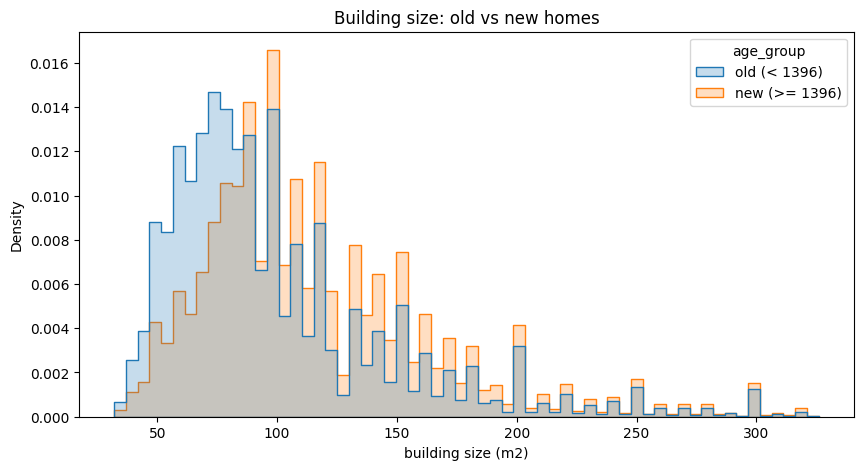

In [21]:
homes = divar.loc[divar["cat2_slug"].isin(["residential-sell", "residential-rent"]) & divar["cat3_slug"].ne("plot-old"),
                  ["building_size", "construction_year", "cat3_slug"]].copy()
homes["year"] = parse_year(homes["construction_year"])
homes = homes.dropna(subset=["year", "building_size"])
homes = homes[log_iqr_mask(homes["building_size"])]
homes["age_group"] = np.where(homes["year"] < 1396, "old (< 1396)", "new (>= 1396)")

old = homes.loc[homes["age_group"].str.startswith("old"), "building_size"]
new = homes.loc[homes["age_group"].str.startswith("new"), "building_size"]

print(homes.groupby("age_group")["building_size"].agg(["count", "mean", "median", "std"]).round(1))

plt.figure(figsize=(10, 5))
sns.histplot(data=homes, x="building_size", hue="age_group", bins=60, stat="density", common_norm=False, element="step")
plt.xlabel("building size (m2)")
plt.title("Building size: old vs new homes")
plt.show()

In [22]:
# H0: mean(old) <= mean(new)   H1: mean(old) > mean(new)
print("levene :", stats.levene(old.sample(5000, random_state=42), new.sample(5000, random_state=42)))
print("welch t:", stats.ttest_ind(old, new, equal_var=False, alternative="greater"))
print("mann-w :", stats.mannwhitneyu(old, new, alternative="greater"))
print("cohen d:", round(cohen_d(old, new), 4))

levene : LeveneResult(statistic=np.float64(25.884619543831743), pvalue=np.float64(3.690281386500177e-07))
welch t: TtestResult(statistic=np.float64(-145.4427418307064), pvalue=np.float64(1.0), df=np.float64(676048.2521562892))
mann-w : MannwhitneyuResult(statistic=np.float64(42503811833.0), pvalue=np.float64(1.0))
cohen d: -0.3535


In [23]:
# the same test inside each property type
rows = []
for cat3, group in homes.groupby("cat3_slug"):
    o = group.loc[group["age_group"].str.startswith("old"), "building_size"]
    n = group.loc[group["age_group"].str.startswith("new"), "building_size"]
    if min(len(o), len(n)) < 30:
        continue
    rows.append({"cat3_slug": cat3, "n_old": len(o), "n_new": len(n),
                 "mean_old": o.mean(), "mean_new": n.mean(),
                 "p_welch_greater": stats.ttest_ind(o, n, equal_var=False, alternative="greater").pvalue,
                 "cohen_d": cohen_d(o, n)})
pd.DataFrame(rows).round(3)

,cat3_slug,n_old,n_new,mean_old,mean_new,p_welch_greater,cohen_d
0,apartment-rent,110989,97686,93.797,115.678,1.0,-0.516
1,apartment-sell,140076,160754,87.763,110.932,1.0,-0.584
2,house-villa-rent,40737,19871,114.665,117.197,1.0,-0.049
3,house-villa-sell,50095,57310,137.282,138.625,1.0,-0.021


<div dir="rtl">

**تفسیر (بعد از اجرا با اعداد نهایی چک شود):**
- اگر p-value آزمون Welch از ۰٫۰۵ بزرگ‌تر باشد H0 رد نمی‌شود و داده از جمله‌ی «قدیما خونه‌ها دلبازتر بود» پشتیبانی نمی‌کند.
  نسخه‌ی اول هم همین نتیجه را داد: میانگین خانه‌های نوساز بزرگ‌تر بود (۱۶۳ در برابر ۱۳۹ متر بعد از فیلتر).
- جدول تفکیکی نشان می‌دهد این نتیجه در هر نوع ملک هم برقرار است یا فقط حاصل ترکیب آپارتمان و ویلا در دو گروه است.
- با صدها هزار نمونه، حتی اختلاف یک متری هم معنادار می‌شود؛ برای قضاوت عملی باید به Cohen's d و اختلاف میانگین‌ها نگاه کرد.

</div>

## آزمون ۳ — آیا سند تجاری با قیمت فروش ملک تجاری رابطه‌ی معنادار دارد؟

<div dir="rtl">

```
H0: mean(price | business deed) == mean(price | no business deed)
H1: the two means differ                                            (two-sided)
```

نسخه‌ی اول این آزمون سه مشکل داشت که در این نسخه رفع شده‌اند:

1. **همه‌ی** آگهی‌ها را مقایسه می‌کرد؛ سؤال درباره‌ی **فروش ملک تجاری** است (`cat2_slug == "commercial-sell"`).
2. قیمت‌های خالی با میانه‌ی شهر پر می‌شدند. این کار هزاران مقدار ساختگی و یکسان به هر دو گروه اضافه می‌کند و تفاوت‌ها را کم‌رنگ می‌کند؛ این‌جا فقط قیمت‌های ثبت‌شده استفاده می‌شود.
3. متن نتیجه «p کمتر از آلفا است پس H0 رد نمی‌شود» می‌گفت که با منطق آزمون نمی‌خواند.

قیمت روی مقیاس لگاریتمی مقایسه می‌شود و Mann-Whitney به‌عنوان آزمون ناپارامتری کنار t-test آمده است.
چون ملک بزرگ‌تر هم گران‌تر است و هم احتمالاً سند تجاری دارد، قیمت هر متر مربع هم جداگانه آزمون شده است.

</div>

In [24]:
commercial = divar.loc[divar["cat2_slug"].eq("commercial-sell"),
                        ["cat3_slug", "price_value", "building_size", "has_business_deed"]].copy()
print(commercial["has_business_deed"].value_counts(dropna=False))

commercial["deed"] = to_flag(commercial["has_business_deed"])
commercial = commercial.dropna(subset=["deed"])
commercial = commercial[log_iqr_mask(commercial["price_value"])]
commercial["deed"] = commercial["deed"].map({1: "with deed", 0: "without deed"})
commercial["log_price"] = np.log(commercial["price_value"])

print()
print(pd.crosstab(commercial["cat3_slug"], commercial["deed"]))
print()
print((commercial.groupby("deed")["price_value"].agg(["count", "mean", "median"]) / [1, 1e9, 1e9]).round(2)
      .rename(columns={"mean": "mean (bn Toman)", "median": "median (bn Toman)"}))

has_business_deed
False    17428
True     17251
NaN       4182
Name: count, dtype: int64

deed                                with deed  without deed
cat3_slug                                                  
industry-agriculture-business-sell       3899          3542
office-sell                              1957          1411
shop-sell                                7235          8015

                count  mean (bn Toman)  median (bn Toman)
deed                                                     
with deed     13091.0            10.15               4.19
without deed  12968.0             8.26               3.20


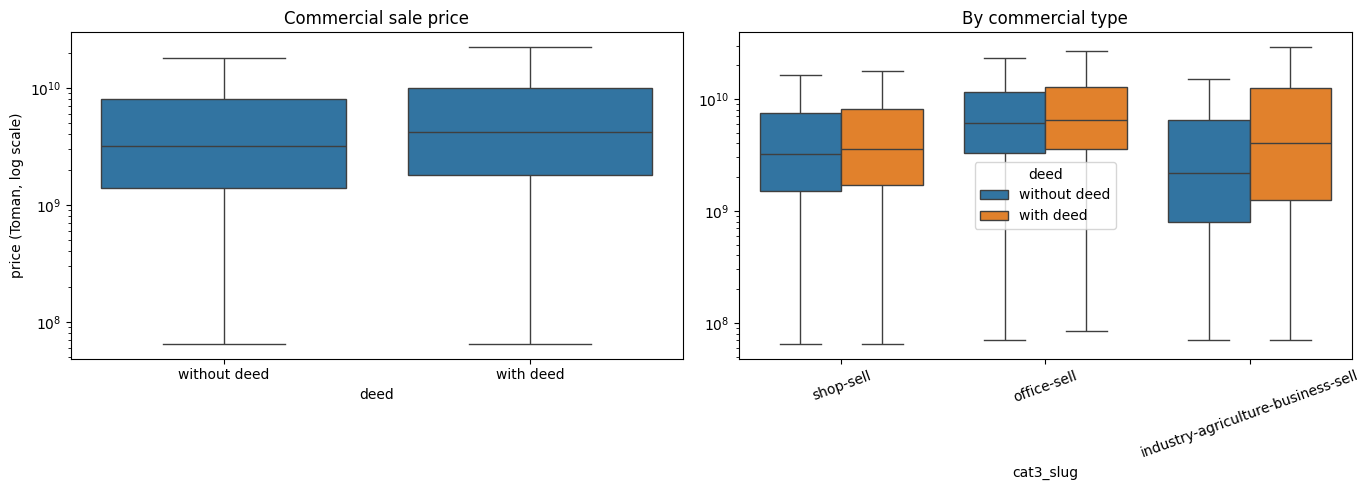

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=commercial, x="deed", y="price_value", showfliers=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_ylabel("price (Toman, log scale)")
axes[0].set_title("Commercial sale price")
sns.boxplot(data=commercial, x="cat3_slug", y="price_value", hue="deed", showfliers=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_ylabel("")
axes[1].set_title("By commercial type")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [26]:
with_deed = commercial.loc[commercial["deed"].eq("with deed"), "log_price"]
without_deed = commercial.loc[commercial["deed"].eq("without deed"), "log_price"]

print("levene :", stats.levene(with_deed, without_deed))
print("welch t (log price):", stats.ttest_ind(with_deed, without_deed, equal_var=False))
print("mann-w           :", stats.mannwhitneyu(with_deed, without_deed))
print("cohen d (log)    :", round(cohen_d(with_deed, without_deed), 4))
print("price ratio of geometric means:", round(np.exp(with_deed.mean() - without_deed.mean()), 3))

levene : LeveneResult(statistic=np.float64(1.959323990310077), pvalue=np.float64(0.16159754010335375))
welch t (log price): TtestResult(statistic=np.float64(14.47401303813336), pvalue=np.float64(2.699646070408839e-47), df=np.float64(26046.218369595623))
mann-w           : MannwhitneyuResult(statistic=np.float64(93722544.0), pvalue=np.float64(5.0109464722216547e-48))
cohen d (log)    : 0.1793
price ratio of geometric means: 1.275


In [27]:
# per type, and price per square metre to take size out of the comparison
sized = commercial[(commercial["building_size"] > 0) & log_iqr_mask(commercial["building_size"])].copy()
sized["log_price_m2"] = np.log(sized["price_value"] / sized["building_size"])

rows = []
for cat3, group in [("all commercial-sell", sized)] + list(sized.groupby("cat3_slug")):
    for column in ["log_price", "log_price_m2"]:
        a = group.loc[group["deed"].eq("with deed"), column]
        b = group.loc[group["deed"].eq("without deed"), column]
        if min(len(a), len(b)) < 30:
            continue
        rows.append({"group": cat3, "measure": column, "n_with": len(a), "n_without": len(b),
                     "ratio_with_vs_without": np.exp(a.mean() - b.mean()),
                     "p_welch": stats.ttest_ind(a, b, equal_var=False).pvalue,
                     "p_mannwhitney": stats.mannwhitneyu(a, b).pvalue})
pd.DataFrame(rows).round(4)

,group,measure,n_with,n_without,ratio_with_vs_without,p_welch,p_mannwhitney
0,all commercial-sell,log_price,12539,12592,1.2545,0.0000,0.0000
1,all commercial-sell,log_price_m2,12539,12592,1.0423,0.1193,0.2268
2,industry-agriculture-business-sell,log_price,3362,3191,1.5934,0.0000,0.0000
3,industry-agriculture-business-sell,log_price_m2,3362,3191,1.3045,0.0000,0.0000
4,office-sell,log_price,1955,1409,1.1543,0.0002,0.0045
5,office-sell,log_price_m2,1955,1409,1.1778,0.0000,0.0000
6,shop-sell,log_price,7222,7992,1.1120,0.0000,0.0000
7,shop-sell,log_price_m2,7222,7992,1.0288,0.1542,0.1706


<div dir="rtl">

**تفسیر (بعد از اجرا با اعداد نهایی چک شود):**
- اگر p-value کمتر از ۰٫۰۵ باشد H0 رد می‌شود و سند تجاری با قیمت رابطه‌ی معنادار دارد. ستون `ratio_with_vs_without` جهت و اندازه‌ی این رابطه را نشان می‌دهد (مثلاً ۱٫۲ یعنی حدود ۲۰٪ گران‌تر).
- اگر نتیجه برای کل قیمت معنادار باشد ولی برای قیمت هر متر نه، اختلاف از اندازه‌ی ملک می‌آید و نه از خود سند.
- این آزمون رابطه را نشان می‌دهد، نه علیت را: ملک‌های دارای سند تجاری معمولاً در محدوده‌های تجاری و خیابان‌های اصلی‌اند.

</div>

## آزمون ۴ — امکانات لاکچری و غیرلاکچری و میانگین قیمت

<div dir="rtl">

امکانات **لاکچری**: استخر، باربیکیو، سونا، جکوزی · امکانات **غیرلاکچری**: آسانسور، پارکینگ، انباری، بالکن.

برای هر امکان:

```
H0: mean(log price | has amenity) == mean(log price | no amenity)
H1: the two means differ
```

**روش، در دو گام:**

۱. **نگاه کلی به نیمه‌ی اول سؤال:** آگهی‌هایی که هر چهار امکان لاکچری را **با هم** دارند (۸۱۹ آگهی، میانگین ۱۱٫۱۵ میلیارد) در برابر بقیه (۱۸٬۳۴۹ آگهی، ۵٫۶ میلیارد). این مقایسه نشان می‌دهد امکانات لاکچری با قیمت بالاتر همراه‌اند، ولی چیزی درباره‌ی نیمه‌ی دوم سؤال نمی‌گوید.

۲. **آزمون جداگانه‌ی هر هشت امکان** روی آگهی‌های فروش مسکونی با یک روش یکسان، تا هر دو نیمه‌ی سؤال کنار هم جواب بگیرند. چون امکانات لاکچری عمدتاً برای ویلا و امکاناتی مثل آسانسور عمدتاً برای آپارتمان ثبت شده‌اند، آزمون داخل هر نوع ملک هم تکرار شده تا اثر نوع ملک با اثر امکان قاطی نشود. چون ۸ آزمون هم‌زمان انجام می‌شود، سطح معناداری با اصلاح بونفرونی ۰٫۰۵/۸ در نظر گرفته شده است.

</div>

In [28]:
LUXURY = ["has_pool", "has_barbecue", "has_sauna", "has_jacuzzi"]
NON_LUXURY = ["has_elevator", "has_parking", "has_warehouse", "has_balcony"]
ALPHA = 0.05 / len(LUXURY + NON_LUXURY)

homes_sale = divar.loc[divar["cat2_slug"].eq("residential-sell") & divar["cat3_slug"].ne("plot-old"),
                       ["cat3_slug", "price_value"] + LUXURY + NON_LUXURY].copy()
homes_sale = homes_sale[log_iqr_mask(homes_sale["price_value"])]
homes_sale["log_price"] = np.log(homes_sale["price_value"])
for column in LUXURY + NON_LUXURY:
    homes_sale[column] = to_flag(homes_sale[column])

# which property types record which amenity
homes_sale.groupby("cat3_slug")[LUXURY + NON_LUXURY].count()

,has_pool,has_barbecue,has_sauna,has_jacuzzi,has_elevator,has_parking,has_warehouse,has_balcony
cat3_slug,,,,,,,,
apartment-sell,1,1,1,1,290461,290462,290462,186992
house-villa-sell,18815,20405,18086,18272,0,111168,111168,111167


In [29]:
def amenity_test(frame, amenity):
    has = frame.loc[frame[amenity].eq(1), "log_price"]
    has_not = frame.loc[frame[amenity].eq(0), "log_price"]
    if min(len(has), len(has_not)) < 30:
        return None
    return {"amenity": amenity, "type": "luxury" if amenity in LUXURY else "non-luxury",
            "n_with": len(has), "n_without": len(has_not),
            "mean_with_bn": np.exp(has).mean() / 1e9, "mean_without_bn": np.exp(has_not).mean() / 1e9,
            "ratio_geo_mean": np.exp(has.mean() - has_not.mean()),
            "cohen_d": cohen_d(has, has_not),
            "p_welch": stats.ttest_ind(has, has_not, equal_var=False).pvalue,
            "p_mannwhitney": stats.mannwhitneyu(has, has_not).pvalue}


overall = pd.DataFrame([r for a in LUXURY + NON_LUXURY if (r := amenity_test(homes_sale, a))])
overall["significant"] = overall["p_welch"] < ALPHA
overall.round(4)

,amenity,type,n_with,n_without,mean_with_bn,mean_without_bn,ratio_geo_mean,cohen_d,p_welch,p_mannwhitney,significant
0,has_pool,luxury,2443,16373,5.9289,4.4459,1.3023,0.3045,0.0000,0.0000,True
1,has_barbecue,luxury,5370,15036,4.7240,4.4593,1.0519,0.0596,0.0002,0.0008,True
2,has_sauna,luxury,941,17146,5.8400,4.5760,1.2175,0.2242,0.0000,0.0000,True
3,has_jacuzzi,luxury,1444,16829,6.5915,4.4877,1.4191,0.3970,0.0000,0.0000,True
4,has_elevator,non-luxury,209987,80474,6.1497,2.8071,1.9367,0.8889,0.0000,0.0000,True
5,has_parking,non-luxury,329118,72512,5.6443,2.5238,1.9927,0.8993,0.0000,0.0000,True
6,has_warehouse,non-luxury,342613,59017,5.4143,3.1459,1.6112,0.5859,0.0000,0.0000,True
7,has_balcony,non-luxury,252294,45865,5.3772,3.3539,1.5771,0.5481,0.0000,0.0000,True


In [30]:
# inside each property type, so villa vs apartment differences do not pose as amenity effects
by_type = pd.DataFrame([dict(r, cat3_slug=cat3)
                        for cat3, group in homes_sale.groupby("cat3_slug")
                        for a in LUXURY + NON_LUXURY if (r := amenity_test(group, a))])
by_type["significant"] = by_type["p_welch"] < ALPHA
by_type.set_index(["cat3_slug", "amenity"]).round(4)

type  n_with  n_without  mean_with_bn  \
cat3_slug        amenity                                                      
apartment-sell   has_elevator   non-luxury  209987      80474        6.1497   
                 has_parking    non-luxury  239177      51285        5.8254   
                 has_warehouse  non-luxury  248780      41682        5.5709   
                 has_balcony    non-luxury  172666      14326        5.4208   
house-villa-sell has_pool           luxury    2443      16372        5.9289   
                 has_barbecue       luxury    5370      15035        4.7240   
                 has_sauna          luxury     941      17145        5.8400   
                 has_jacuzzi        luxury    1444      16828        6.5915   
                 has_parking    non-luxury   89941      21227        5.1627   
                 has_warehouse  non-luxury   93833      17335        4.9990   
                 has_balcony    non-luxury   79628      31539        5.2827   

                                mean_without_bn  ratio_geo_mean  cohen_d  \
cat3_slug        amenity                                                   
apartment-sell   has_elevator            2.8071          1.9367   0.8889   
                 has_parking             2.4167          2.0692   1.0027   
                 has_warehouse           3.1508          1.6209   0.6191   
                 has_balcony             3.5657          1.4149   0.4489   
house-villa-sell has_pool                4.4461          1.3022   0.3044   
                 has_barbecue            4.4596          1.0518   0.0595   
                 has_sauna               4.5762          1.2174   0.2241   
                 has_jacuzzi             4.4880          1.4190   0.3969   
                 has_parking             2.7823          1.7974   0.6866   
                 has_warehouse           3.1341          1.5704   0.5109   
                 has_balcony             3.2578          1.5804   0.5244   

                                p_welch  p_mannwhitney  significant  
cat3_slug        amenity                                             
apartment-sell   has_elevator    0.0000         0.0000         True  
                 has_parking     0.0000         0.0000         True  
                 has_warehouse   0.0000         0.0000         True  
                 has_balcony     0.0000         0.0000         True  
house-villa-sell has_pool        0.0000         0.0000         True  
                 has_barbecue    0.0002         0.0008         True  
                 has_sauna       0.0000         0.0000         True  
                 has_jacuzzi     0.0000         0.0000         True  
                 has_parking     0.0000         0.0000         True  
                 has_warehouse   0.0000         0.0000         True  
                 has_balcony     0.0000         0.0000         True

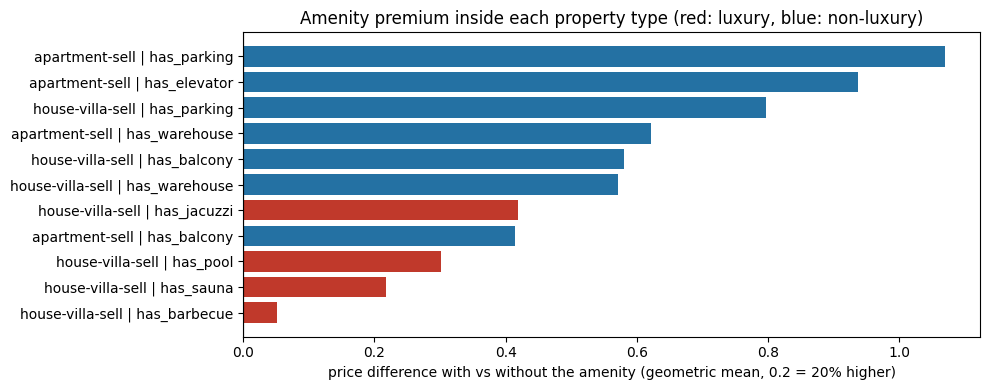

In [31]:
plot_data = by_type.assign(label=lambda t: t["cat3_slug"] + " | " + t["amenity"]).sort_values("ratio_geo_mean")
colours = np.where(plot_data["type"].eq("luxury"), "#c0392b", "#2471a3")

plt.figure(figsize=(10, max(4, 0.35 * len(plot_data))))
plt.barh(plot_data["label"], plot_data["ratio_geo_mean"] - 1, color=colours)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("price difference with vs without the amenity (geometric mean, 0.2 = 20% higher)")
plt.title("Amenity premium inside each property type (red: luxury, blue: non-luxury)")
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:**

- **نیمه‌ی اول سؤال تأیید می‌شود:** امکانات لاکچری قیمت را بالا می‌برند. آگهی‌های دارای هر چهار امکان تقریباً دو برابر بقیه قیمت دارند (p ≈ 0.0001).
- **نیمه‌ی دوم هم تأیید می‌شود:** هر هشت امکان، حتی با آستانه‌ی سخت‌گیرانه‌ی بونفرونی، معنادار درمی‌آیند.
- **نتیجه‌ی غیرمنتظره:** اندازه‌ی اثر امکانات غیرلاکچری **بزرگ‌تر** است، نه کوچک‌تر. پارکینگ (۱٫۹۹ برابر) و آسانسور (۱٫۹۴ برابر) بالاترین نسبت را دارند، در حالی که استخر ۱٫۳ و باربیکیو ۱٫۰۵ برابر است. کوهن d هم همین ترتیب را نشان می‌دهد: ۰٫۹۰ برای پارکینگ در برابر ۰٫۰۶ برای باربیکیو.
- توضیح این نتیجه در ترکیب داده است: آسانسور و پارکینگ در عمل نشانه‌ی کیفیت کل ساختمان‌اند، در حالی که امکانات لاکچری تقریباً فقط برای ویلا ثبت می‌شوند و ویلا از پیش گران است. به همین دلیل مقایسه‌ی داخل هر نوع ملک از جدول کلی مهم‌تر است.

</div>